In [1]:
from urllib.parse import urlparse
import pickle
import pandas as pd
import psycopg2
from psycopg2 import pool
from concurrent.futures import ThreadPoolExecutor, as_completed
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Build dataset for license change analysis

## Retrieve all license files that were removed or modfied

In [3]:
connection_pool = psycopg2.pool.ThreadedConnectionPool(
    minconn=1,
    maxconn=100,  # Adjust based on your PostgreSQL max_connections and credentials
    host="localhost",
    database="altered_histories",
    user="rapaport",
    password="WHT6rNYJknNme3lS"
)

In [6]:
def execute_query(query):
    conn = connection_pool.getconn()
    try:
        with conn.cursor() as cursor:
            cursor.execute("SET max_parallel_workers = 24;")
            cursor.execute("SET max_parallel_workers_per_gather = 4;")
            
            # Execute your actual query
            cursor.execute(query)
            return cursor.fetchall()
    finally:
        connection_pool.putconn(conn)

In [7]:
query = "SELECT * FROM modified_files WHERE (branch = 'refs/heads/main' OR branch = 'refs/heads/master') AND (lower(path) LIKE '%license%' OR lower(path) LIKE '%licence%')"
results = execute_query(query)

In [8]:
columns = ['id', 'origin', 'revision_id', 'branch', 'snapshot_id', 'path', 'status']
df_license = pd.DataFrame(results, columns=columns)
print(f"Total rows: {len(df_license):,}")
df_license.head()

Total rows: 796,987


,id,origin,revision_id,branch,snapshot_id,path,status
0,196,https://github.com/nspool/hello-coreanimation,swh:1:rev:16a526f38b5f3b16f5f9adc8d494e4dca8e1e9e4,refs/heads/master,swh:1:snp:800f9b2f2959d9cd79f3d2ed5963add9442e9342,./LICENSE,NotFound
1,106,https://github.com/SkullTech/iitd-proxylogin,swh:1:rev:8431b2d3b52f7ea8ce1e7ec01f895c4bf0359817,refs/heads/master,swh:1:snp:ccbcdc3a226288260dba4bb4f829c84bfdbd2605,./LICENSE,Modified
2,165,https://github.com/shashankp/spin,swh:1:rev:11618192317c53d9f5c822329f7f15b6983b98ca,refs/heads/master,swh:1:snp:0585754b61153b163f7ed7940beb32256f3486bb,./LICENSE,NotFound
3,2733,https://github.com/JiefeiC/octopus,swh:1:rev:deef2e4500274c0f643731f27c602326268f8b7c,refs/heads/master,swh:1:snp:3be535e8d00191e816587c2add7ec7e0e6125926,./LICENSE,Modified
4,727,https://github.com/JanusStudios/KillMeNow,swh:1:rev:2ec91b5de8a1d249fd5cfca11a4f20c6f64c9ad6,refs/heads/master,swh:1:snp:1ccadf0199baf88ade7e9efd8aaba2fbb4ca3f45,./LICENSE,Modified


## Generate urls of license files
We need to access the content of each license files, and we do so through the web api of Software Heritage

In [9]:
print(f"We find {len(df_license):,} license files in the main/master branch\nthat were modified or deleted through the commits' history.")
df_NotFound = df_license.loc[df_license['status'] == "NotFound"]
print(f"Among them, {len(df_NotFound):,} were removed")
df_Modified = df_license.loc[df_license['status'] == "Modified"].copy()
print(f"Among them, {len(df_Modified):,} were modified")

We find 796,987 license files in the main/master branch
that were modified or deleted through the commits' history.
Among them, 719,202 were removed
Among them, 77,785 were modified


We only focus on the `Modified` files because then, we can compare the altered version with the current version.

In [10]:
from swh_license_files import *

In [12]:
df_Modified['Rev-License-Path'] = df_Modified.apply(
    lambda row: generate_swh_url(row['revision_id'], row['path']),
    axis=1
)

In [13]:
df_Modified['Snap-License-Path'] = df_Modified.apply(
    lambda row: generate_swh_url(row['snapshot_id'], row['path'], row['branch']),
    axis=1
)

### Checkpoint
We save the temporary dataframe to `../results/license_files_with_path.pkl`.

In [ ]:
with open('../../data/license_files_with_path.pkl', 'wb') as f:
    pickle.dump(df_Modified, f)

## Scan Licenses

The following scan takes hours.
We recommand you run the script outside of the notebook.
```sh
python3 swh_license_files.py
```
The results are stored in `../../data/license_full_part2.pkl`.

## Retrieve family license

In [14]:
from license_categorization import *
import pickle
import pandas as pd

In [15]:
LICENSE_FAMILIES = {}
with open("../../data/license_families.pkl", 'rb') as f:
    LICENSE_FAMILIES = pickle.load(f)

In [16]:
df = pd.DataFrame
with open("../../data/license_full_part2.pkl", 'rb') as f:
    df = pickle.load(f)

In [17]:
df.head()

,origin,revision,branch,snapshot_without,path,status,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
0,https://github.com/SkullTech/iitd-proxylogin,swh:1:rev:8431b2d3b52f7ea8ce1e7ec01f895c4bf0359817,refs/heads/master,swh:1:snp:ccbcdc3a226288260dba4bb4f829c84bfdbd2605,./LICENSE,Modified,https://archive.softwareheritage.org/browse/revision/8431b2d3b52f7ea8ce1e7ec01f895c4bf0359817/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/ccbcdc3a226288260dba4bb4f829c84bfdbd2605/directory/?branch=refs/heads/master&path=LICENSE,mit,mit
4,https://github.com/JanusStudios/KillMeNow,swh:1:rev:2ec91b5de8a1d249fd5cfca11a4f20c6f64c9ad6,refs/heads/master,swh:1:snp:1ccadf0199baf88ade7e9efd8aaba2fbb4ca3f45,./LICENSE,Modified,https://archive.softwareheritage.org/browse/revision/2ec91b5de8a1d249fd5cfca11a4f20c6f64c9ad6/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/1ccadf0199baf88ade7e9efd8aaba2fbb4ca3f45/directory/?branch=refs/heads/master&path=LICENSE,apache-2.0,apache-2.0
6,https://github.com/yoosuf/yoosuf.github.io,swh:1:rev:fe49ec0e71c1c1c8912abde31bc98c8f988c162d,refs/heads/master,swh:1:snp:7766112a89d7c5a4aff6a6c94e0a1b86e5417fc6,./LICENSE,Modified,https://archive.softwareheritage.org/browse/revision/fe49ec0e71c1c1c8912abde31bc98c8f988c162d/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/7766112a89d7c5a4aff6a6c94e0a1b86e5417fc6/directory/?branch=refs/heads/master&path=LICENSE,mit,mit
9,https://github.com/JiefeiC/octopus,swh:1:rev:deef2e4500274c0f643731f27c602326268f8b7c,refs/heads/master,swh:1:snp:3be535e8d00191e816587c2add7ec7e0e6125926,./LICENSE,Modified,https://archive.softwareheritage.org/browse/revision/deef2e4500274c0f643731f27c602326268f8b7c/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/3be535e8d00191e816587c2add7ec7e0e6125926/directory/?branch=refs/heads/master&path=LICENSE,mit,mit
10,https://github.com/fercosmig/Forum,swh:1:rev:d36bab5122e742d9fd45be7ade0b45a5a8347947,refs/heads/master,swh:1:snp:7c9e6afe808c3a5c7f86d40ef073d1028974b08c,./LICENSE,Modified,https://archive.softwareheritage.org/browse/revision/d36bab5122e742d9fd45be7ade0b45a5a8347947/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/7c9e6afe808c3a5c7f86d40ef073d1028974b08c/directory/?branch=refs/heads/master&path=LICENSE,apache-2.0,gpl-2.0


In [ ]:
df['from-family'] = df['Rev-License-Scanned'].apply(lambda x: get_all_license_family(x, LICENSE_FAMILIES) if pd.notna(x) else set())
df['to-family'] = df['Snap-License-Scanned'].apply(lambda x: get_all_license_family(x, LICENSE_FAMILIES) if pd.notna(x) else set())

# Display first few rows to verify
df[['Rev-License-Scanned', 'from-family', 'Snap-License-Scanned', 'to-family']].head()

,Rev-License-Scanned,from-family,Snap-License-Scanned,to-family
0,mit,{mit},mit,{mit}
4,apache-2.0,{apache},apache-2.0,{apache}
6,mit,{mit},mit,{mit}
9,mit,{mit},mit,{mit}
10,apache-2.0,{apache},gpl-2.0,{gpl}


In [20]:
df['category'] = df[['from-family', 'to-family']].apply(lambda x: classify_license_change(x['from-family'], x['to-family']), axis=1)

We store the final dataset in `../../data/license_full.pkl`

In [21]:
print(f'out of {len(df):,} modified files in main, master branch')
df_without_na = df[~df['Rev-License-Scanned'].isna()].reset_index(drop=True)
df_without_na = df_without_na[~df_without_na['Snap-License-Scanned'].isna()].reset_index(drop=True)
print(f'we were able to scan both licenses in {len(df_without_na):,} cases')

out of 77,776 modified files in main, master branch
we were able to scan both licenses in 65,688 cases


In [22]:
with open('../../data/license_full.pkl', 'wb') as f:
    pickle.dump(df, f)

In [23]:
unknown = df_without_na[df_without_na['category']=="Unknown"]

In [24]:
print(f'among those we find {len(unknown):,} unknown changes')

among those we find 575 unknown changes


Repartition of license change categories:
                Count  Percentage
category                         
Update          52424   79.807575
Full Change      9244   14.072586
Partial Change   3445    5.244489
Unknown           575    0.875350


/tmp/ipykernel_3090882/2557567394.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, count + 0.5, f"{category_stats['Percentage'][i]:.1f}%",


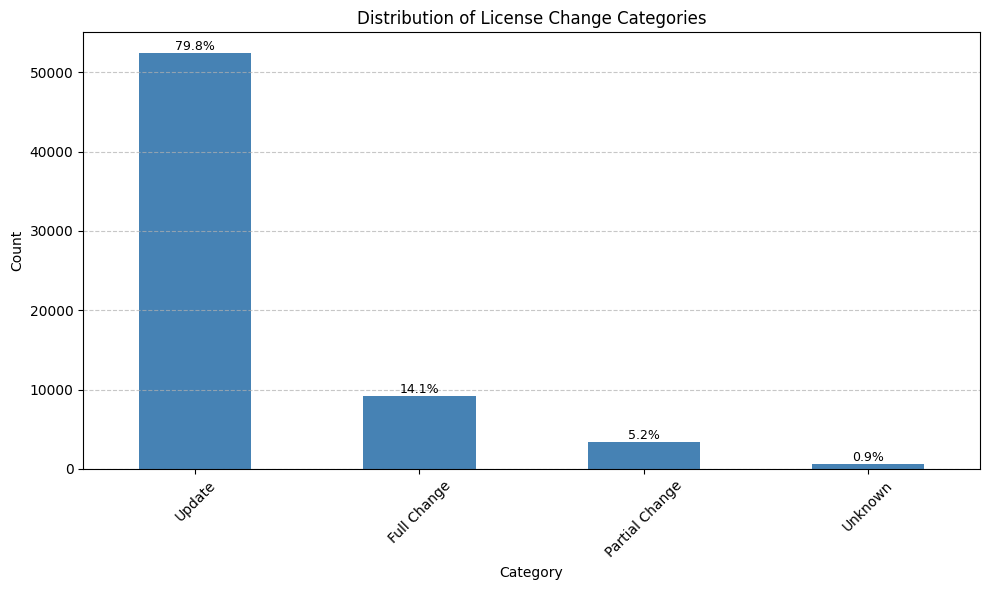

In [25]:
# Calculate and display the repartition of license change categories
category_counts = df_without_na['category'].value_counts()
category_percentages = df_without_na['category'].value_counts(normalize=True) * 100

# Combine counts and percentages
category_stats = pd.DataFrame({
    'Count': category_counts,
    'Percentage': category_percentages
}).sort_values(by='Count', ascending=False)

# Display stats
print("Repartition of license change categories:")
print(category_stats)

# Create a bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
category_stats['Count'].plot(kind='bar', color='steelblue')
plt.title('Distribution of License Change Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(category_stats['Count']):
    plt.text(i, count + 0.5, f"{category_stats['Percentage'][i]:.1f}%", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Cross with popular repositories

In [26]:
df_stars = pd.read_pickle("../../data/stars_without_dup.pkl")

In [27]:
stars_dict = df_stars.set_index('origin')['stars'].to_dict()

In [28]:
df_without_na['stars'] = df_without_na['origin'].map(stars_dict)

IOStream.flush timed out


In [29]:
with open("../../data/license_no_na_with_stars", 'wb') as f:
    pickle.dump(df_without_na, f)

In [ ]:
# df_without_na = pd.read_pickle("../../data/license_no_na_with_stars")

In [30]:
len(df_without_na['origin'].drop_duplicates())

32169

In [31]:
df_1000 = df_without_na[df_without_na['stars'] >= 1000]

In [32]:
len(df_1000['origin'].drop_duplicates())

76